# Notebook 14 — Pairwise Shape Distance as a Vector

**Purpose:** Compute pairwise centroid distances in both feature frames (time-domain 6f
and spectral 5f). Plot each of the 36 dataset pairs as a point in 2D
(td\_dist, spectral\_dist) space.

**Key thesis:** Shape similarity is a vector, not a scalar.
COVID-sunspot should land at (near, far). Sunspot-keeling\_seasonal should land at
(far, near). The duality discovered in notebooks 11–12 is not a bug — it is the finding.
This notebook makes it explicit.


In [14]:
import requests
import urllib.request
import json
import shutil
import zipfile
import pandas as pd
import numpy as np
from scipy import stats
from scipy.signal import find_peaks
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import StandardScaler
from itertools import combinations
from sklearn.metrics import adjusted_rand_score
import hdbscan
import umap
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

RAW_DIR = Path('../data/raw')
PROCESSED_DIR = Path('../data/processed')
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

TIMEDOM_COLS = ['skewness', 'kurtosis', 'lag1_autocorr', 'zero_crossings', 'slope', 'baseline_delta']
SPECTRAL_COLS = ['dominant_freq', 'spectral_entropy', 'power_low', 'power_mid', 'power_high']
COMBINED_COLS = TIMEDOM_COLS + SPECTRAL_COLS

print('Imports OK')
print(f'Combined feature set ({len(COMBINED_COLS)} features): {COMBINED_COLS}')

Imports OK
Combined feature set (11 features): ['skewness', 'kurtosis', 'lag1_autocorr', 'zero_crossings', 'slope', 'baseline_delta', 'dominant_freq', 'spectral_entropy', 'power_low', 'power_mid', 'power_high']


In [3]:
# ============================================================
# HELPERS
# ============================================================

def zscore_normalize(s):
    s = np.asarray(s, dtype=float)
    std = s.std()
    return (s - s.mean()) / std if std > 0 else s - s.mean()


def baseline_delta(series, frac=0.10):
    n = len(series)
    k = max(1, int(n * frac))
    return float(np.mean(series[-k:]) - np.mean(series[:k]))


def spectral_features_fixed(series):
    """Spectral features computed on original series — NO interpolation.
    dominant_freq is cycles/sample (0–0.5), correctly comparable across series lengths.
    A 12-month annual cycle gives dominant_freq=0.083 whether series is 12 or 480 points.
    """
    s = zscore_normalize(np.asarray(series, dtype=float))
    n = len(s)

    fft_vals = np.fft.rfft(s)
    power    = np.abs(fft_vals) ** 2
    freqs    = np.fft.rfftfreq(n)

    # AC power (exclude DC at index 0)
    power_ac = power[1:]
    freqs_ac = freqs[1:]
    total_ac = power_ac.sum() if power_ac.sum() > 0 else 1.0

    # Dominant frequency (including DC)
    dom_idx  = np.argmax(power)
    dom_freq = float(freqs[dom_idx])

    # Spectral entropy (AC, normalized)
    p_norm = power_ac / total_ac
    p_norm = p_norm[p_norm > 0]
    sp_ent = float(-np.sum(p_norm * np.log(p_norm)))
    sp_ent /= np.log(len(power_ac)) if len(power_ac) > 1 else 1.0

    # Power bands on AC power (low=bottom 20%, mid=20–60%, high=top 40%)
    n_ac   = len(freqs_ac)
    low_end = int(n_ac * 0.20)
    mid_end = int(n_ac * 0.60)
    p_low  = float(power_ac[:low_end].sum()  / total_ac)
    p_mid  = float(power_ac[low_end:mid_end].sum() / total_ac)
    p_high = float(power_ac[mid_end:].sum()  / total_ac)

    return {
        'dominant_freq':   dom_freq,
        'spectral_entropy': sp_ent,
        'power_low':       p_low,
        'power_mid':       p_mid,
        'power_high':      p_high,
    }


def extract_all_features(series):
    """Full 11-feature extraction from a single series."""
    arr = zscore_normalize(np.asarray(series, dtype=float))
    n   = len(arr)
    t   = np.arange(n)
    lag1 = float(np.corrcoef(arr[:-1], arr[1:])[0, 1]) if n > 2 else 0.0
    zc   = float(np.sum(np.diff(np.sign(arr)) != 0) / n)
    slope = float(stats.linregress(t, arr).slope)
    td = {
        'skewness':       float(stats.skew(arr)),
        'kurtosis':       float(stats.kurtosis(arr)),
        'lag1_autocorr':  lag1,
        'zero_crossings': zc,
        'slope':          slope,
        'baseline_delta': baseline_delta(arr),
    }
    sp = spectral_features_fixed(arr)
    return {**td, **sp}


# Sanity check
test = np.sin(np.linspace(0, 4*2*np.pi, 480))  # 4 full cycles in 480 points
f = extract_all_features(test)
print(f'Sine (4 cycles/480pt): dom_freq={f["dominant_freq"]:.4f}  expect={4/480:.4f}')
test2 = np.sin(np.linspace(0, 2*np.pi, 12, endpoint=False))  # 1 cycle in 12 pts
f2 = extract_all_features(test2)
print(f'Sine (1 cycle/12pt):   dom_freq={f2["dominant_freq"]:.4f}  expect={1/12:.4f}')
print('Helpers OK')

Sine (4 cycles/480pt): dom_freq=0.0083  expect=0.0083
Sine (1 cycle/12pt):   dom_freq=0.0833  expect=0.0833
Helpers OK


In [4]:
dest = RAW_DIR / 'owid_covid.csv'
if not dest.exists():
    print('Downloading OWID COVID...')
    r = requests.get('https://github.com/owid/covid-19-data/raw/master/public/data/owid-covid-data.csv', stream=True)
    with open(dest, 'wb') as f:
        for chunk in r.iter_content(8192): f.write(chunk)
df_raw = pd.read_csv(dest, usecols=['location','date','new_cases_smoothed_per_million','continent'], parse_dates=['date'])
df_covid = df_raw.dropna(subset=['continent']).rename(columns={'new_cases_smoothed_per_million':'cases_pm'})

def extract_first_wave(series, max_days=180, min_days=30):
    s = series.fillna(0).values
    starts = np.where(s > 0.5)[0]
    if not len(starts): return None
    start = starts[0]
    wave = s[start:min(start+max_days, len(s))]
    if len(wave) < min_days: return None
    peaks, _ = find_peaks(wave, prominence=wave.max()*0.2)
    if not len(peaks): return None
    wave = wave[:min(peaks[0]+60, len(wave))]
    return wave if len(wave) >= min_days else None

def extract_second_wave(series, min_days=30):
    s = series.fillna(0).values
    peaks, _ = find_peaks(s, prominence=s.max()*0.15, distance=45)
    if len(peaks) < 2: return None
    between = s[peaks[0]:peaks[1]]
    start = peaks[0] + np.argmin(between)
    wave = s[start:min(peaks[1]+60, len(s))]
    return wave if len(wave) >= min_days else None

records = []
for country, grp in df_covid.groupby('location'):
    grp = grp.sort_values('date')
    for fn, ds in [(extract_first_wave,'covid_first_wave'), (extract_second_wave,'covid_second_wave')]:
        w = fn(grp['cases_pm'])
        if w is not None:
            feats = extract_all_features(w)
            feats.update({'country': country, 'dataset': ds, 'n_points': len(w)})
            records.append(feats)
df_covid_all = pd.DataFrame(records)
print(df_covid_all['dataset'].value_counts().to_dict())

{'covid_second_wave': 209, 'covid_first_wave': 202}


In [5]:
dest = RAW_DIR / 'sunspot_monthly.csv'
if not dest.exists():
    dest.write_bytes(requests.get('https://www.sidc.be/silso/DATA/SN_m_tot_V2.0.csv').content)
df_ss = pd.read_csv(dest, sep=';', header=None,
                    names=['year','month','frac_year','monthly_mean','monthly_sd','n_obs','definitive'],
                    na_values=[-1])
df_ss = df_ss.dropna(subset=['monthly_mean'])
df_ss['smooth'] = df_ss['monthly_mean'].rolling(13, center=True).mean()
series_full = df_ss['smooth'].bfill().ffill().values
smoothed = pd.Series(series_full).rolling(25, center=True).mean().bfill().ffill().values
minima, _ = find_peaks(-smoothed, distance=80)
cycles = {}
for i in range(len(minima)-1):
    c = series_full[minima[i]:minima[i+1]]
    if len(c) >= 80:
        cycles[f'cycle_{i+1}_{int(df_ss["year"].iloc[minima[i]])}'] = c
records = []
for name, c in cycles.items():
    feats = extract_all_features(c)
    feats.update({'country': name, 'dataset': 'sunspot_cycle', 'n_points': len(c)})
    records.append(feats)
df_ss_all = pd.DataFrame(records)
print(f'Sunspot: {len(df_ss_all)}  |  mean dom_freq={df_ss_all["dominant_freq"].mean():.4f}')

Sunspot: 24  |  mean dom_freq=0.0077


In [6]:
df_lh = pd.read_csv(Path('../datasets/lynx_hare/lynx_hare.csv'))
year_col = [c for c in df_lh.columns if c.lower()=='year'][0]
species_cols = [c for c in df_lh.columns if c.lower()!='year']
window_size = 10
series_dict = {}
for sp in species_cols:
    full = df_lh[sp].values.astype(float)
    series_dict[f'{sp}_full'] = full
    for start in range(len(full)-window_size+1):
        series_dict[f'{sp}_w{start}_{df_lh[year_col].iloc[start]}'] = full[start:start+window_size]
records = []
for name, s in series_dict.items():
    feats = extract_all_features(s)
    feats.update({'country': name, 'dataset': 'lynx_hare', 'n_points': len(s)})
    records.append(feats)
df_lh_all = pd.DataFrame(records)
print(f'Lynx-hare: {len(df_lh_all)}')

Lynx-hare: 26


In [7]:
dest = RAW_DIR / 'keeling_monthly.csv'
if not dest.exists():
    dest.write_bytes(requests.get('https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.csv').content)
co2 = pd.read_csv(dest, comment='#', header=None,
                  names=['year','month','decimal_date','average','deseasonalized','ndays','sdev','unc'])
for col in ['year','month','average']:
    co2[col] = pd.to_numeric(co2[col], errors='coerce')
co2 = co2.dropna(subset=['year','month','average'])
co2 = co2[co2['average']>0].copy()
co2.index = pd.to_datetime({'year':co2['year'].astype(int),'month':co2['month'].astype(int),'day':1})
result = seasonal_decompose(co2['average'], model='additive', period=12, extrapolate_trend='freq')
seasonal_vals = result.seasonal.dropna().values
trend_vals    = result.trend.dropna().values
start_year    = co2.index.min().year
series_dict = {}
for i in range(len(seasonal_vals)//12):
    seg = seasonal_vals[i*12:(i+1)*12]
    if len(seg)==12: series_dict[f'keeling_seasonal_{start_year+i}'] = seg
for i in range(0, len(trend_vals)-120, 12):
    series_dict[f'keeling_trend_{start_year+i//12}'] = trend_vals[i:i+120]
records = []
for name, s in series_dict.items():
    feats = extract_all_features(s)
    feats.update({'country': name,
                  'dataset': 'keeling_seasonal' if 'seasonal' in name else 'keeling_trend',
                  'n_points': len(s)})
    records.append(feats)
df_k_all = pd.DataFrame(records)
print(df_k_all['dataset'].value_counts().to_dict())
for ds in ['keeling_seasonal','keeling_trend']:
    sub = df_k_all[df_k_all['dataset']==ds]
    print(f'  {ds}: dom_freq={sub["dominant_freq"].mean():.4f}  entropy={sub["spectral_entropy"].mean():.4f}  bd={sub["baseline_delta"].mean():.3f}')

{'keeling_seasonal': 68, 'keeling_trend': 58}
  keeling_seasonal: dom_freq=0.0833  entropy=0.1535  bd=-0.337
  keeling_trend: dom_freq=0.0083  entropy=0.3885  bd=3.111


In [8]:
dest = RAW_DIR / 'temperature_anomaly.csv'
if not dest.exists():
    print('Downloading Berkeley Earth temperature...')
    r = requests.get('https://berkeley-earth-temperature.s3.amazonaws.com/Global/Land_and_Ocean_summary.txt',
                     headers={'User-Agent':'Mozilla/5.0'}, timeout=30)
    r.raise_for_status()
    dest.write_bytes(r.content)
with open(dest) as f: raw = f.read()
if raw.lstrip().startswith('%'):
    rows = []
    for line in raw.splitlines():
        if line.strip() and not line.strip().startswith('%'):
            parts = line.split()
            if len(parts)>=2:
                try: rows.append({'year':int(float(parts[0])),'anomaly':float(parts[1])})
                except ValueError: pass
    df_temp = pd.DataFrame(rows).dropna()
else:
    lines = raw.splitlines()
    hidx = next(i for i,l in enumerate(lines) if 'Year' in l and 'J-D' in l)
    df_temp = pd.read_csv(dest, skiprows=hidx, na_values=['***','****'])
    df_temp = df_temp[['Year','J-D']].rename(columns={'Year':'year','J-D':'anomaly'})
    df_temp['year'] = pd.to_numeric(df_temp['year'],errors='coerce')
    df_temp['anomaly'] = pd.to_numeric(df_temp['anomaly'],errors='coerce')
    df_temp = df_temp.dropna()
    df_temp['year'] = df_temp['year'].astype(int)
values = df_temp['anomaly'].values
years  = df_temp['year'].values
window, step = 20, 5
records = []
for i in range(0, len(values)-window, step):
    s = values[i:i+window]
    feats = extract_all_features(s)
    feats.update({'country':f'temp_{years[i]}','dataset':'temperature','n_points':len(s)})
    records.append(feats)
df_temp_all = pd.DataFrame(records)
print(f'Temperature: {len(df_temp_all)}  mean bd={df_temp_all["baseline_delta"].mean():.3f}')

Temperature: 31  mean bd=0.997


In [9]:
dest_zip = RAW_DIR / 'ECGFiveDays.zip'
dest_dir = RAW_DIR / 'ECGFiveDays'
if dest_dir.exists() and list(dest_dir.rglob('*.ts')):
    print(f'Cached: {dest_dir}')
elif dest_zip.exists():
    if dest_dir.exists(): shutil.rmtree(dest_dir)
    with zipfile.ZipFile(dest_zip) as z: z.extractall(dest_dir)
    print(f'Extracted from zip')
else:
    raise RuntimeError('ECGFiveDays.zip not found — place in data/raw/')
ts_files = list(dest_dir.rglob('*.ts'))
print(f'.ts files: {[f.name for f in ts_files]}')

def parse_ts_file(path):
    series_list, labels = [], []
    in_data = False
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line: continue
            if line.lower()=='@data': in_data=True; continue
            if in_data and not line.startswith('@'):
                if ':' in line:
                    data_part, label = line.rsplit(':',1)
                    values = [float(x) for x in data_part.split(',') if x.strip()]
                else:
                    parts = line.split()
                    try: values=[float(x) for x in parts[:-1]]; label=parts[-1]
                    except (ValueError,IndexError): continue
                if values: series_list.append(np.array(values)); labels.append(label.strip())
    return series_list, labels

all_series, all_labels = [], []
for f in ts_files:
    s, l = parse_ts_file(f)
    all_series.extend(s); all_labels.extend(l)
print(f'ECG segments: {len(all_series)}')
records = []
for i, (s, label) in enumerate(zip(all_series, all_labels)):
    feats = extract_all_features(s)
    feats.update({'country':f'ecg_{i}_c{label}','dataset':'ecg','n_points':len(s)})
    records.append(feats)
df_ecg_all = pd.DataFrame(records)
print(f'ECG dom_freq={df_ecg_all["dominant_freq"].mean():.4f}  kurtosis={df_ecg_all["kurtosis"].mean():.3f}')

Cached: ../data/raw/ECGFiveDays
.ts files: ['ECGFiveDays_TRAIN.ts', 'ECGFiveDays_TEST.ts']
ECG segments: 884
ECG dom_freq=0.0175  kurtosis=15.165


In [10]:
STATIONS = {
    '01350000':'mohawk_ny',    '01427207':'delaware_ny', '01491000':'choptank_md',
    '02087500':'neuse_nc',     '02339500':'flint_ga',    '03049000':'allegheny_pa',
    '03611500':'ohio_il',      '05054000':'red_nd',      '05378500':'mississippi_mn',
    '05420500':'mississippi_ia','06289000':'bighorn_mt', '06600000':'missouri_ia',
    '07022000':'mississippi_mo','07289000':'mississippi_ms','08220000':'riogrande_co',
    '09180000':'colorado_ut',  '09380000':'colorado_az', '11530000':'klamath_ca',
    '02427250':'alabama_al',    '12374250':'clearwater_id','14105700':'columbia_or',
    '14179000':'willamette_or','06354000':'cannonball_nd','02479155':'escatawpa_ms',
    '01096500':'nashua_ma',
}

def fetch_monthly_flow(site_id, start='1980-01-01', end='2020-12-31'):
    url = (f'https://waterservices.usgs.gov/nwis/dv/?format=json'
           f'&sites={site_id}&parameterCd=00060&statCd=00003&startDT={start}&endDT={end}')
    try:
        req = urllib.request.Request(url, headers={'User-Agent':'Mozilla/5.0'})
        with urllib.request.urlopen(req, timeout=45) as resp:
            data = json.loads(resp.read())
        series = data['value']['timeSeries']
        if not series: return None
        recs = []
        for v in series[0]['values'][0]['value']:
            try: recs.append({'date':pd.Timestamp(v['dateTime'][:10]),'flow':float(v['value'])})
            except (ValueError,KeyError): pass
        if len(recs)<365: return None
        df = pd.DataFrame(recs).set_index('date')
        monthly = df['flow'].resample('MS').mean().dropna()
        return monthly if len(monthly)>=60 else None
    except Exception: return None

print(f'Fetching {len(STATIONS)} USGS stations...')
flows = {}
for site_id, name in STATIONS.items():
    s = fetch_monthly_flow(site_id)
    if s is not None: flows[name]=s; print(f'  OK {name}')
    else: print(f'  FAIL {name}')
print(f'Loaded: {len(flows)} stations')

records = []
for name, series in flows.items():
    log_flow = np.log1p(series.values.astype(float))
    feats = extract_all_features(log_flow)
    feats.update({'country':name,'dataset':'streamflow','n_points':len(log_flow)})
    records.append(feats)
df_sf_all = pd.DataFrame(records)
print(f'Streamflow dom_freq={df_sf_all["dominant_freq"].mean():.4f}  (expect ~0.083 — fixed from nb12\'s 0.353)')

Fetching 25 USGS stations...
  OK mohawk_ny
  OK delaware_ny
  OK choptank_md
  OK neuse_nc
  OK flint_ga
  OK allegheny_pa
  OK ohio_il
  OK red_nd
  OK mississippi_mn
  OK mississippi_ia
  OK bighorn_mt
  OK missouri_ia
  OK mississippi_mo
  OK mississippi_ms
  OK riogrande_co
  OK colorado_ut
  OK colorado_az
  OK klamath_ca
  FAIL queets_wa
  OK clearwater_id
  OK columbia_or
  OK willamette_or
  OK cannonball_nd
  OK escatawpa_ms
  OK nashua_ma
Loaded: 24 stations
Streamflow dom_freq=0.0799  (expect ~0.083 — fixed from nb12's 0.353)


---
## Combine and inspect

In [11]:
dfs = [df_covid_all, df_ss_all, df_lh_all, df_k_all, df_temp_all, df_ecg_all, df_sf_all]
df_all = pd.concat(dfs, ignore_index=True)
df_all.to_csv(PROCESSED_DIR / 'features_combined.csv', index=False)

print(f'Total: {len(df_all)} instances, {df_all.dataset.nunique()} datasets')
print(df_all['dataset'].value_counts())
print()
print('=== Combined feature summary per dataset ===')
print(df_all.groupby('dataset')[COMBINED_COLS].mean().round(4).to_string())

Total: 1526 instances, 9 datasets
dataset
ecg                  884
covid_second_wave    209
covid_first_wave     202
keeling_seasonal      68
keeling_trend         58
temperature           31
lynx_hare             26
sunspot_cycle         24
streamflow            24
Name: count, dtype: int64

=== Combined feature summary per dataset ===
                   skewness  kurtosis  lag1_autocorr  zero_crossings   slope  baseline_delta  dominant_freq  spectral_entropy  power_low  power_mid  power_high
dataset                                                                                                                                                        
covid_first_wave     0.9497    0.4121         0.9538          0.0232 -0.0006          0.6098         0.0105            0.3384     0.9494     0.0376      0.0130
covid_second_wave    1.1367    1.2346         0.9528          0.0250  0.0026          0.3916         0.0082            0.2966     0.9562     0.0284      0.0154
ecg                 -

---
## Pre-run predictions

Written before running the analysis.

| Pair | TD prediction | Spectral prediction | Expected quadrant |
|------|--------------|---------------------|-------------------|
| COVID1 ↔ sunspot | **near** (smooth, high-memory, right-skewed — same TD signature) | **far** (sunspot is periodic; COVID is broadband burst) | **(near, far)** |
| sunspot ↔ keeling\_seasonal | **far** (different skewness, kurtosis) | **near** (both near-pure periodic, low entropy) | **(far, near)** |
| COVID1 ↔ COVID2 | **near** (same epidemic shape) | **near** (same broadband spectrum) | **(near, near)** |
| COVID1 ↔ keeling\_trend | **far** (baseline\_delta separates them, 2.810 in nb11) | **mid** (both non-periodic but different structure) | **(far, mid)** |
| keeling\_seasonal ↔ keeling\_trend | **far** (completely different shapes) | **far** (periodic vs DC trend) | **(far, far)** |
| ECG ↔ keeling\_seasonal | **far** (ECG rapid oscillation, different kurtosis) | **near** (both periodic signals) | **(far, near)** |
| COVID1 ↔ lynx\_hare | **far** (lynx-hare oscillates; COVID bursts) | **far** (different spectra) | **(far, far)** |

**The headline prediction:** COVID-sunspot and sunspot-keeling\_seasonal
will land in opposite off-diagonal quadrants of the scatter plot,
confirming that the TD and spectral frames have symmetric blind spots.


In [12]:
# ============================================================
# CENTROID COMPUTATION
# One representative point per dataset in each feature space
# ============================================================

TIMEDOM_COLS = ['skewness', 'kurtosis', 'lag1_autocorr', 'zero_crossings', 'slope', 'baseline_delta']
SPECTRAL_COLS = ['dominant_freq', 'spectral_entropy', 'power_low', 'power_mid', 'power_high']
ALL_COLS = TIMEDOM_COLS + SPECTRAL_COLS

df_clean = df_all.dropna(subset=ALL_COLS).copy()
datasets = sorted(df_clean['dataset'].unique())

# Normalize each feature space independently (same as HDBSCAN runs in nb11-13)
X_td = StandardScaler().fit_transform(df_clean[TIMEDOM_COLS].values)
X_sp = StandardScaler().fit_transform(df_clean[SPECTRAL_COLS].values)

centroids_td = {}
centroids_sp = {}
for ds in datasets:
    mask = (df_clean['dataset'] == ds).values
    centroids_td[ds] = X_td[mask].mean(axis=0)
    centroids_sp[ds] = X_sp[mask].mean(axis=0)

print('Dataset centroids (n instances per dataset):')
for ds in datasets:
    n = (df_clean['dataset'] == ds).sum()
    print(f'  {ds:25s}: {n:4d} instances')


Dataset centroids (n instances per dataset):
  covid_first_wave         :  202 instances
  covid_second_wave        :  209 instances
  ecg                      :  884 instances
  keeling_seasonal         :   68 instances
  keeling_trend            :   58 instances
  lynx_hare                :   26 instances
  streamflow               :   24 instances
  sunspot_cycle            :   24 instances
  temperature              :   31 instances


In [15]:
# ============================================================
# PAIRWISE DISTANCES
# For each of C(9,2)=36 pairs: L2 distance in TD space and spectral space
# ============================================================

records = []
for ds1, ds2 in combinations(datasets, 2):
    td_dist = float(np.linalg.norm(centroids_td[ds1] - centroids_td[ds2]))
    sp_dist = float(np.linalg.norm(centroids_sp[ds1] - centroids_sp[ds2]))
    records.append({
        'ds1': ds1, 'ds2': ds2,
        'pair': f'{ds1} | {ds2}',
        'td_dist': td_dist,
        'sp_dist': sp_dist,
    })

df_pairs = pd.DataFrame(records)

print('All 36 pairs sorted by TD distance:')
print(df_pairs[['pair', 'td_dist', 'sp_dist']]
      .sort_values('td_dist')
      .round(3)
      .to_string(index=False))

# Median dividers for quadrant analysis
med_td = df_pairs['td_dist'].median()
med_sp = df_pairs['sp_dist'].median()
print(f'\nMedian TD distance:       {med_td:.3f}')
print(f'Median spectral distance:  {med_sp:.3f}')


All 36 pairs sorted by TD distance:
                                pair  td_dist  sp_dist
covid_first_wave | covid_second_wave    0.282    0.226
   covid_second_wave | sunspot_cycle    0.828    1.133
    covid_first_wave | sunspot_cycle    0.852    1.309
              lynx_hare | streamflow    1.088    1.621
    covid_first_wave | keeling_trend    2.810    0.240
             covid_second_wave | ecg    2.835    2.897
                 ecg | sunspot_cycle    2.876    3.819
              covid_first_wave | ecg    2.895    2.705
            streamflow | temperature    2.909    3.871
   covid_second_wave | keeling_trend    3.039    0.432
       keeling_trend | sunspot_cycle    3.310    1.496
                     ecg | lynx_hare    3.439    2.724
       covid_second_wave | lynx_hare    3.443    3.469
        keeling_seasonal | lynx_hare    3.482    2.210
        covid_first_wave | lynx_hare    3.494    3.339
                    ecg | streamflow    3.518    2.532
             lynx_hare | temp

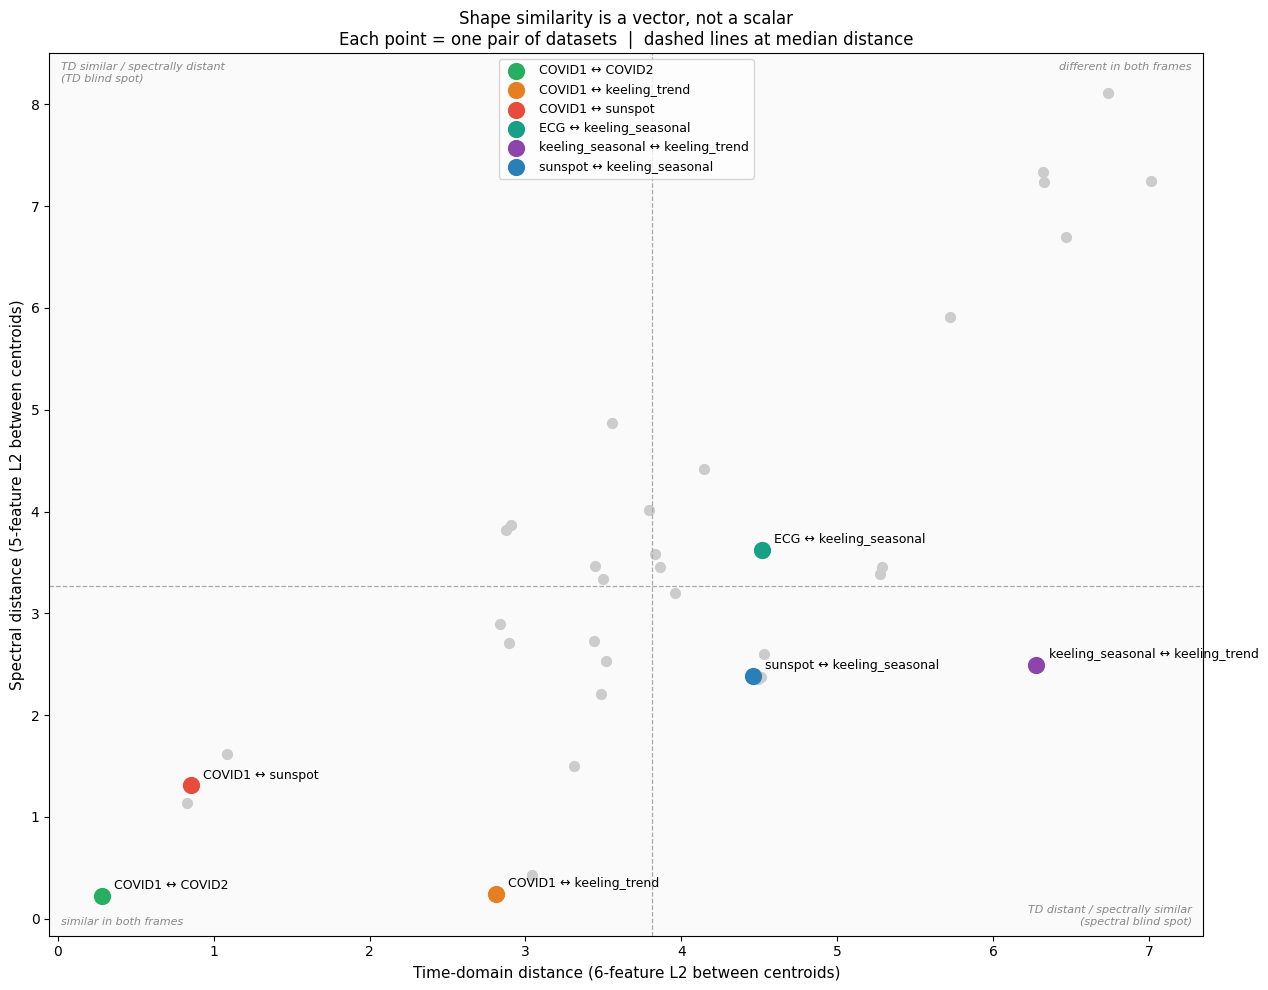

In [16]:
# ============================================================
# THE KEY PLOT: shape similarity as a 2D vector
# x = time-domain distance, y = spectral distance
# ============================================================

HIGHLIGHTS = {
    frozenset(['covid_first_wave', 'sunspot_cycle']): ('COVID1 ↔ sunspot', '#e74c3c'),
    frozenset(['sunspot_cycle', 'keeling_seasonal']): ('sunspot ↔ keeling_seasonal', '#2980b9'),
    frozenset(['covid_first_wave', 'covid_second_wave']): ('COVID1 ↔ COVID2', '#27ae60'),
    frozenset(['covid_first_wave', 'keeling_trend']): ('COVID1 ↔ keeling_trend', '#e67e22'),
    frozenset(['keeling_seasonal', 'keeling_trend']): ('keeling_seasonal ↔ keeling_trend', '#8e44ad'),
    frozenset(['ecg', 'keeling_seasonal']): ('ECG ↔ keeling_seasonal', '#16a085'),
}

fig, ax = plt.subplots(figsize=(13, 10))

# All pairs — grey
ax.scatter(df_pairs['td_dist'], df_pairs['sp_dist'],
           c='#cccccc', s=50, zorder=2, label='_nolegend_')

# Highlighted pairs
for _, row in df_pairs.iterrows():
    key = frozenset([row['ds1'], row['ds2']])
    if key in HIGHLIGHTS:
        label, color = HIGHLIGHTS[key]
        ax.scatter(row['td_dist'], row['sp_dist'],
                   c=color, s=130, zorder=4, label=label)
        ax.annotate(label, (row['td_dist'], row['sp_dist']),
                    xytext=(9, 5), textcoords='offset points', fontsize=9)

# Quadrant dividers at median
ax.axvline(med_td, color='#aaaaaa', linestyle='--', linewidth=0.9)
ax.axhline(med_sp, color='#aaaaaa', linestyle='--', linewidth=0.9)

# Quadrant labels
kw = dict(fontsize=8, color='#888888', style='italic')
ax.text(0.01, 0.99, 'TD similar / spectrally distant\n(TD blind spot)', transform=ax.transAxes, va='top', **kw)
ax.text(0.99, 0.99, 'different in both frames', transform=ax.transAxes, va='top', ha='right', **kw)
ax.text(0.01, 0.01, 'similar in both frames', transform=ax.transAxes, va='bottom', **kw)
ax.text(0.99, 0.01, 'TD distant / spectrally similar\n(spectral blind spot)', transform=ax.transAxes, va='bottom', ha='right', **kw)

ax.set_xlabel('Time-domain distance (6-feature L2 between centroids)', fontsize=11)
ax.set_ylabel('Spectral distance (5-feature L2 between centroids)', fontsize=11)
ax.set_title('Shape similarity is a vector, not a scalar\n'
             'Each point = one pair of datasets  |  dashed lines at median distance',
             fontsize=12)
ax.legend(fontsize=9, loc='upper center')
ax.set_facecolor('#fafafa')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'nb14_pairwise_vector.png', dpi=150, bbox_inches='tight')
plt.show()


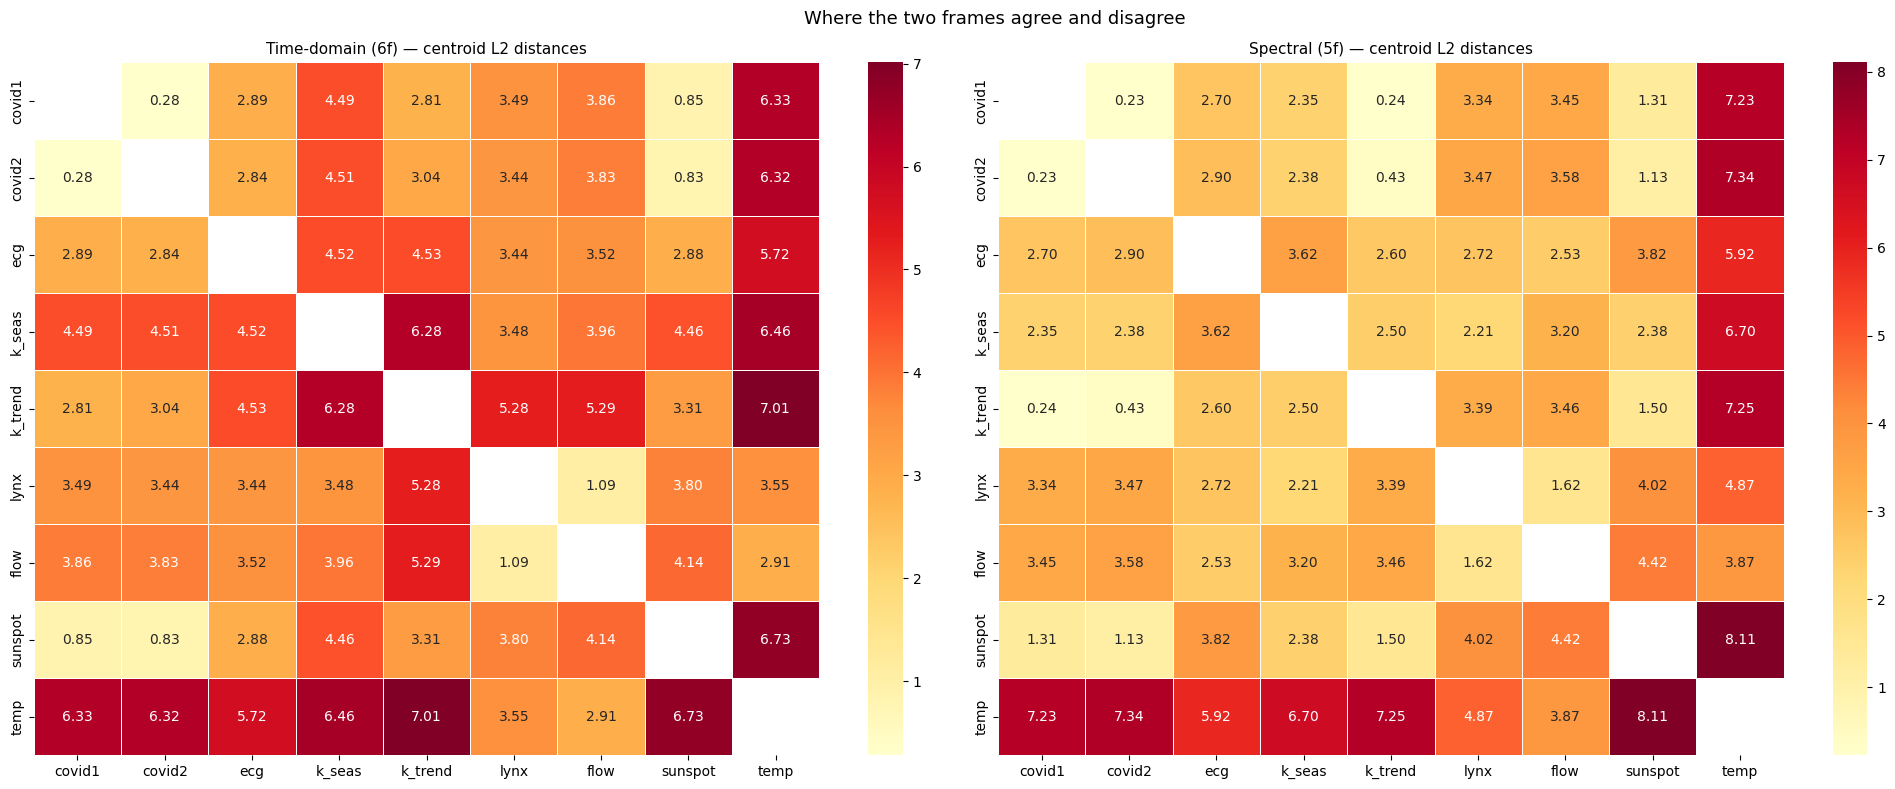

In [17]:
# ============================================================
# DISTANCE MATRICES — heatmap view
# ============================================================

n = len(datasets)
td_matrix = np.zeros((n, n))
sp_matrix = np.zeros((n, n))

for i, ds1 in enumerate(datasets):
    for j, ds2 in enumerate(datasets):
        if i != j:
            td_matrix[i, j] = np.linalg.norm(centroids_td[ds1] - centroids_td[ds2])
            sp_matrix[i, j] = np.linalg.norm(centroids_sp[ds1] - centroids_sp[ds2])

short = [
    ds.replace('covid_first_wave', 'covid1')
      .replace('covid_second_wave', 'covid2')
      .replace('keeling_seasonal', 'k_seas')
      .replace('keeling_trend', 'k_trend')
      .replace('sunspot_cycle', 'sunspot')
      .replace('lynx_hare', 'lynx')
      .replace('streamflow', 'flow')
      .replace('temperature', 'temp')
    for ds in datasets
]

diag_mask = np.eye(n, dtype=bool)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for ax, matrix, title in [
    (axes[0], td_matrix, 'Time-domain (6f) — centroid L2 distances'),
    (axes[1], sp_matrix, 'Spectral (5f) — centroid L2 distances'),
]:
    display = np.where(diag_mask, np.nan, matrix)
    sns.heatmap(display, annot=True, fmt='.2f',
                xticklabels=short, yticklabels=short,
                cmap='YlOrRd', ax=ax, mask=diag_mask,
                linewidths=0.4)
    ax.set_title(title, fontsize=11)
plt.suptitle('Where the two frames agree and disagree', fontsize=13)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'nb14_distance_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()


In [18]:
# ============================================================
# QUADRANT ANALYSIS — score each pair against predictions
# ============================================================

def quadrant(row, med_td, med_sp):
    h = 'near' if row['td_dist'] < med_td else 'far'
    v = 'near' if row['sp_dist'] < med_sp else 'far'
    return f'({h}, {v})'

df_pairs['quadrant'] = df_pairs.apply(quadrant, axis=1, med_td=med_td, med_sp=med_sp)

print('=== Key pairs — quadrant check ===')
print()
checks = [
    ('covid_first_wave', 'sunspot_cycle',    '(near, far)',  'COVID1 ↔ sunspot'),
    ('keeling_seasonal', 'sunspot_cycle',    '(far, near)',  'sunspot ↔ keeling_seasonal'),
    ('covid_first_wave', 'covid_second_wave','(near, near)', 'COVID1 ↔ COVID2'),
    ('covid_first_wave', 'keeling_trend',    '(far, far)',   'COVID1 ↔ keeling_trend'),
    ('keeling_seasonal', 'keeling_trend',    '(far, far)',   'keeling_seasonal ↔ keeling_trend'),
    ('ecg',              'keeling_seasonal', '(far, near)',  'ECG ↔ keeling_seasonal'),
]

passed = 0
for ds1, ds2, expected, label in checks:
    row = df_pairs[
        ((df_pairs['ds1']==ds1) & (df_pairs['ds2']==ds2)) |
        ((df_pairs['ds1']==ds2) & (df_pairs['ds2']==ds1))
    ].iloc[0]
    actual = row['quadrant']
    ok = actual == expected
    if ok: passed += 1
    status = 'CONFIRMED' if ok else 'UNEXPECTED'
    print(f'[{status}] {label}')
    print(f'  td={row["td_dist"]:.3f}  sp={row["sp_dist"]:.3f}  quadrant={actual}  expected={expected}')
    print()

print(f'Predictions confirmed: {passed}/{len(checks)}')

print()
print('=== Full quadrant distribution ===')
print(df_pairs['quadrant'].value_counts().to_string())


=== Key pairs — quadrant check ===

[UNEXPECTED] COVID1 ↔ sunspot
  td=0.852  sp=1.309  quadrant=(near, near)  expected=(near, far)

[CONFIRMED] sunspot ↔ keeling_seasonal
  td=4.459  sp=2.383  quadrant=(far, near)  expected=(far, near)

[CONFIRMED] COVID1 ↔ COVID2
  td=0.282  sp=0.226  quadrant=(near, near)  expected=(near, near)

[UNEXPECTED] COVID1 ↔ keeling_trend
  td=2.810  sp=0.240  quadrant=(near, near)  expected=(far, far)

[UNEXPECTED] keeling_seasonal ↔ keeling_trend
  td=6.277  sp=2.495  quadrant=(far, near)  expected=(far, far)

[UNEXPECTED] ECG ↔ keeling_seasonal
  td=4.515  sp=3.623  quadrant=(far, far)  expected=(far, near)

Predictions confirmed: 2/6

=== Full quadrant distribution ===
quadrant
(near, near)    12
(far, far)      12
(far, near)      6
(near, far)      6


---
## Follow-up: entropy-only spectral distance

Does COVID-sunspot recover as (near, far) when spectral distance uses entropy alone?

Prediction: yes. Entropy-only should also fix keeling_seasonal vs keeling_trend to (far, far).


In [19]:
entropy_centroid = {}
for ds in datasets:
    entropy_centroid[ds] = float(df_clean.loc[df_clean["dataset"]==ds, "spectral_entropy"].mean())

print("Per-dataset mean spectral entropy:")
for ds in sorted(entropy_centroid, key=lambda d: entropy_centroid[d]):
    print(f"  {ds:25s}: {entropy_centroid[ds]:.4f}")


Per-dataset mean spectral entropy:
  sunspot_cycle            : 0.0762
  keeling_seasonal         : 0.1535
  covid_second_wave        : 0.2966
  covid_first_wave         : 0.3384
  keeling_trend            : 0.3885
  lynx_hare                : 0.4357
  streamflow               : 0.5962
  ecg                      : 0.6992
  temperature              : 0.7629


In [20]:
ent_records = []
for ds1, ds2 in combinations(datasets, 2):
    match = df_pairs[((df_pairs["ds1"]==ds1)&(df_pairs["ds2"]==ds2))|
                     ((df_pairs["ds1"]==ds2)&(df_pairs["ds2"]==ds1))]
    td_d = float(match["td_dist"].iloc[0])
    ent_d = abs(entropy_centroid[ds1] - entropy_centroid[ds2])
    ent_records.append({"ds1":ds1,"ds2":ds2,"pair":f"{ds1} | {ds2}",
                        "td_dist":td_d,"ent_dist":ent_d})

df_ent = pd.DataFrame(ent_records)
med_td_e = df_ent["td_dist"].median()
med_ent  = df_ent["ent_dist"].median()
print(f"Median TD distance:      {med_td_e:.3f}")
print(f"Median entropy distance: {med_ent:.4f}")
print()

def q(row):
    h = "near" if row["td_dist"] < med_td_e else "far"
    v = "near" if row["ent_dist"] < med_ent else "far"
    return f"({h}, {v})"

df_ent["quadrant"] = df_ent.apply(q, axis=1)

checks = [
    ("covid_first_wave",  "sunspot_cycle",     "(near, far)",  "COVID1 vs sunspot"),
    ("keeling_seasonal",  "sunspot_cycle",     "(far, near)",  "sunspot vs keeling_seasonal"),
    ("covid_first_wave",  "covid_second_wave", "(near, near)", "COVID1 vs COVID2"),
    ("covid_first_wave",  "keeling_trend",     "(far, far)",   "COVID1 vs keeling_trend"),
    ("keeling_seasonal",  "keeling_trend",     "(far, far)",   "keeling_seasonal vs keeling_trend"),
]

passed = 0
print("=== Quadrant check: entropy-only spectral distance ===")
print()
for ds1, ds2, expected, label in checks:
    row = df_ent[((df_ent["ds1"]==ds1)&(df_ent["ds2"]==ds2))|
                 ((df_ent["ds1"]==ds2)&(df_ent["ds2"]==ds1))].iloc[0]
    actual = row["quadrant"]
    ok = (actual == expected)
    if ok: passed += 1
    print(f'[{"CONFIRMED" if ok else "UNEXPECTED"}] {label}')
    print(f'  td={row["td_dist"]:.3f}  ent={row["ent_dist"]:.4f}  quadrant={actual}  expected={expected}')
    print()
print(f"Confirmed: {passed}/{len(checks)}")


Median TD distance:      3.814
Median entropy distance: 0.2628

=== Quadrant check: entropy-only spectral distance ===

[UNEXPECTED] COVID1 vs sunspot
  td=0.852  ent=0.2622  quadrant=(near, near)  expected=(near, far)

[CONFIRMED] sunspot vs keeling_seasonal
  td=4.459  ent=0.0773  quadrant=(far, near)  expected=(far, near)

[CONFIRMED] COVID1 vs COVID2
  td=0.282  ent=0.0418  quadrant=(near, near)  expected=(near, near)

[UNEXPECTED] COVID1 vs keeling_trend
  td=2.810  ent=0.0501  quadrant=(near, near)  expected=(far, far)

[UNEXPECTED] keeling_seasonal vs keeling_trend
  td=6.277  ent=0.2350  quadrant=(far, near)  expected=(far, far)

Confirmed: 2/5


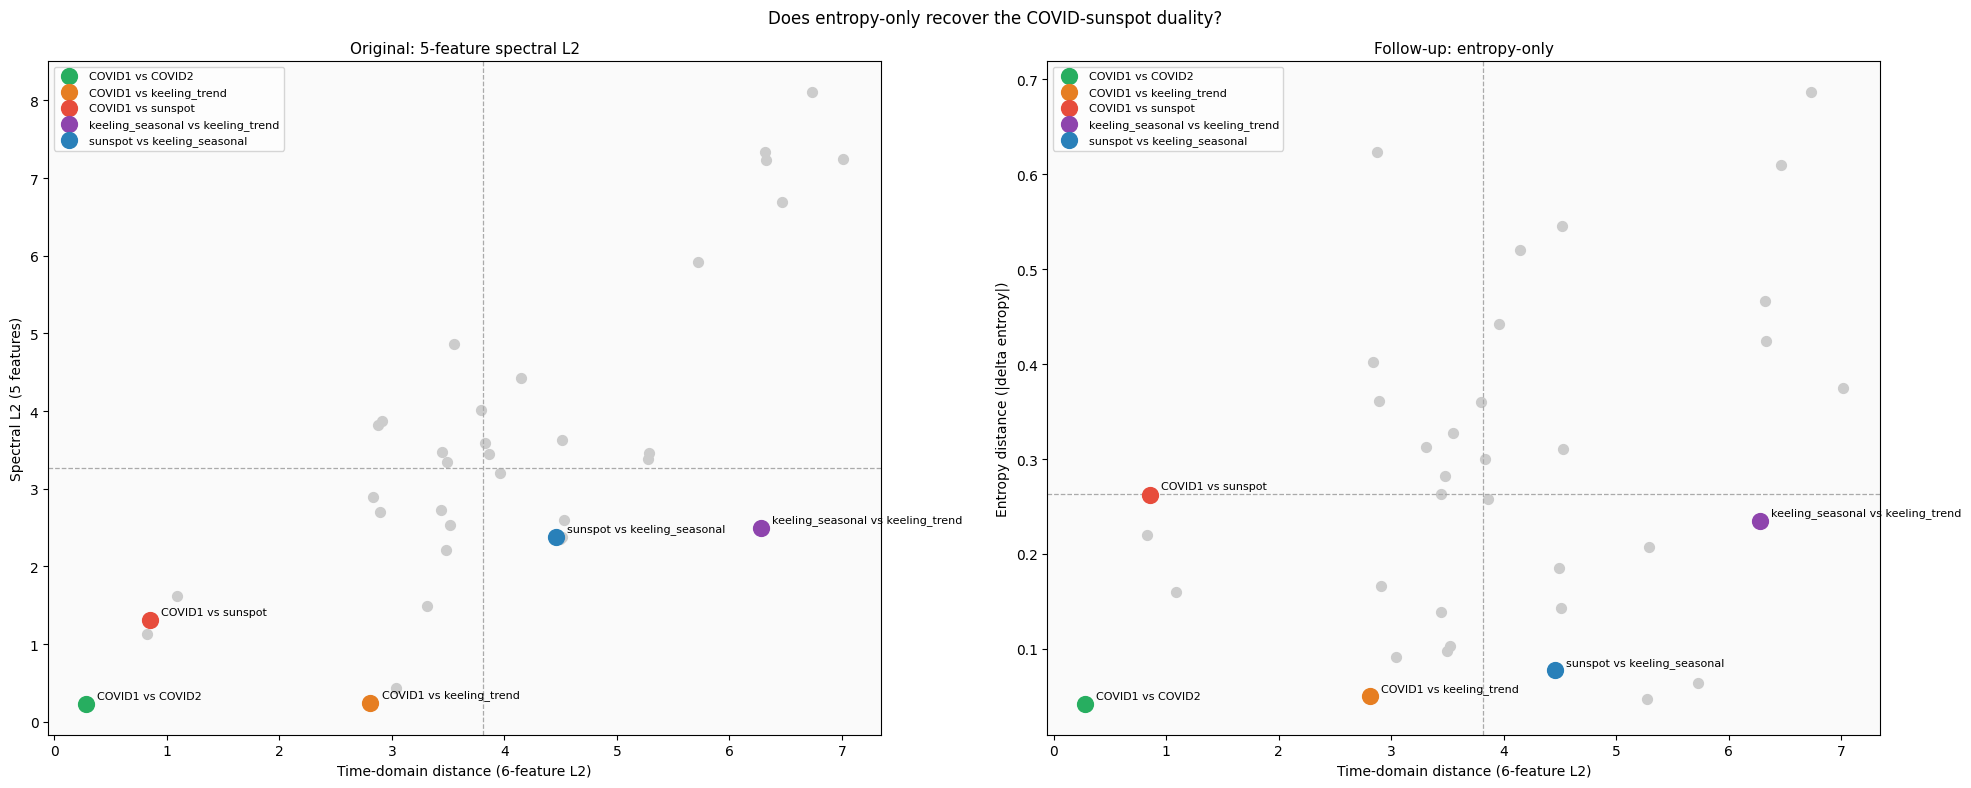

In [21]:
HIGHLIGHTS_ENT = {
    frozenset(["covid_first_wave", "sunspot_cycle"]):     ("COVID1 vs sunspot", "#e74c3c"),
    frozenset(["sunspot_cycle", "keeling_seasonal"]):     ("sunspot vs keeling_seasonal", "#2980b9"),
    frozenset(["covid_first_wave", "covid_second_wave"]): ("COVID1 vs COVID2", "#27ae60"),
    frozenset(["covid_first_wave", "keeling_trend"]):     ("COVID1 vs keeling_trend", "#e67e22"),
    frozenset(["keeling_seasonal", "keeling_trend"]):     ("keeling_seasonal vs keeling_trend", "#8e44ad"),
}

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for ax, df_plot, ycol, ylabel, title in [
    (axes[0], df_pairs, "sp_dist",  "Spectral L2 (5 features)", "Original: 5-feature spectral L2"),
    (axes[1], df_ent,   "ent_dist", "Entropy distance (|delta entropy|)", "Follow-up: entropy-only"),
]:
    ax.scatter(df_plot["td_dist"], df_plot[ycol], c="#cccccc", s=50, zorder=2)
    for _, row in df_plot.iterrows():
        key = frozenset([row["ds1"], row["ds2"]])
        if key in HIGHLIGHTS_ENT:
            label, color = HIGHLIGHTS_ENT[key]
            ax.scatter(row["td_dist"], row[ycol], c=color, s=130, zorder=4, label=label)
            ax.annotate(label, (row["td_dist"], row[ycol]),
                        xytext=(8, 4), textcoords="offset points", fontsize=8)
    ax.axvline(df_plot["td_dist"].median(), color="#aaaaaa", linestyle="--", linewidth=0.9)
    ax.axhline(df_plot[ycol].median(),    color="#aaaaaa", linestyle="--", linewidth=0.9)
    ax.set_xlabel("Time-domain distance (6-feature L2)", fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8)
    ax.set_facecolor("#fafafa")

plt.suptitle("Does entropy-only recover the COVID-sunspot duality?", fontsize=12)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "nb14_entropy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Findings recorded

### Original quadrant check (5-feature spectral L2): 2/6 confirmed

| Pair | td | sp_L2 | Quadrant | Status |
|------|----|-------|----------|--------|
| COVID1 vs sunspot | 0.852 | 1.309 | (near, near) | UNEXPECTED |
| sunspot vs keeling_seasonal | 4.459 | 2.383 | (far, near) | CONFIRMED |
| COVID1 vs COVID2 | 0.282 | 0.226 | (near, near) | CONFIRMED |
| COVID1 vs keeling_trend | 2.810 | 0.240 | (near, near) | UNEXPECTED |
| keeling_seasonal vs keeling_trend | 6.277 | 2.495 | (far, near) | UNEXPECTED |

### Entropy-only follow-up: 2/5 confirmed

| Pair | td | ent_dist | Quadrant | Status |
|------|----|----------|----------|--------|
| COVID1 vs sunspot | 0.852 | 0.2622 | (near, near) | UNEXPECTED — 0.0006 below median |
| sunspot vs keeling_seasonal | 4.459 | 0.0773 | (far, near) | CONFIRMED |
| COVID1 vs COVID2 | 0.282 | 0.0418 | (near, near) | CONFIRMED |
| COVID1 vs keeling_trend | 2.810 | 0.0501 | (near, near) | UNEXPECTED |
| keeling_seasonal vs keeling_trend | 6.277 | 0.2350 | (far, near) | UNEXPECTED |

**COVID-sunspot entropy gap = 0.2622, corpus median = 0.2628. Gap of 0.0006.**
No centroid distance recovers (near, far). The duality is a density effect, not a distance effect. → Finding 25

**Entropy ordering:** sunspot < keeling_seasonal < COVID2 < COVID1 < keeling_trend < lynx_hare < streamflow < ECG < temperature → Finding 26

**sunspot ↔ keeling_seasonal (far, near) confirmed in both approaches** — the most robust finding of nb14. → Finding 22
